# VRPTW Results Analysis (Matplotlib)

This notebook analyzes benchmark and tabu-search outputs from this repository.

Goals:
- Load latest comparison CSV and iteration log JSONL.
- Compare initial vs final objective values.
- Visualize convergence and phase behavior.
- Report lightweight runtime and quality summary metrics.

## 1. Set Up Notebook Environment

Configure reproducibility and repository paths used by the analysis.

In [1]:
from pathlib import Path
import random

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Resolve repository root even if notebook is opened from another cwd
repo_root = Path.cwd()
if not (repo_root / "results").exists() and (repo_root.parent / "results").exists():
    repo_root = repo_root.parent

results_dir = repo_root / "results"
logs_dir = results_dir / "logs"
solutions_dir = results_dir / "solutions"

print(f"Repository root: {repo_root}")
print(f"Logs dir exists: {logs_dir.exists()}")
print(f"Solutions dir exists: {solutions_dir.exists()}")

Repository root: c:\Users\Jed\Desktop\9raya\heuristiques
Logs dir exists: True
Solutions dir exists: True


## 2. Import Dependencies

Import required libraries and print key versions.

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pandas: 2.3.3
numpy: 2.2.6
matplotlib: 3.10.8


## 3. Define Reusable Functions

Helpers for file discovery, safe loading, cleaning, and summary metrics.

In [3]:
def find_latest_file(directory: Path, pattern: str):
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    return files[0] if files else None


def load_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def clean_comparison_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "initial_distance" in out.columns:
        out["initial_distance"] = pd.to_numeric(out["initial_distance"], errors="coerce")
    if "final_distance" in out.columns:
        out["final_distance"] = pd.to_numeric(out["final_distance"], errors="coerce")

    if "feasible" in out.columns:
        out["feasible"] = out["feasible"].astype(str).str.lower().isin(["true", "1", "yes"])
    else:
        out["feasible"] = True

    return out


def summary_metrics(df: pd.DataFrame) -> pd.DataFrame:
    feasible_df = df[df["feasible"] & df["final_distance"].notna()].copy()

    best_idx = feasible_df["final_distance"].idxmin() if len(feasible_df) else None
    best_row = feasible_df.loc[best_idx] if best_idx is not None else None

    data = {
        "metric": [
            "total_runs",
            "feasible_runs",
            "best_final_distance",
            "median_final_distance",
            "best_init_method",
            "best_operators",
        ],
        "value": [
            len(df),
            int(df["feasible"].sum()),
            float(feasible_df["final_distance"].min()) if len(feasible_df) else np.nan,
            float(feasible_df["final_distance"].median()) if len(feasible_df) else np.nan,
            best_row["init_method"] if best_row is not None and "init_method" in best_row else None,
            best_row["operators"] if best_row is not None and "operators" in best_row else None,
        ],
    }
    return pd.DataFrame(data)

## 4. Load and Validate Input Data

Locate latest CSV/JSONL files and validate required fields before analysis.

In [4]:
latest_csv = find_latest_file(solutions_dir, "comparison_*.csv")
latest_log = find_latest_file(logs_dir, "*.jsonl")

print(f"Latest CSV: {latest_csv}")
print(f"Latest log: {latest_log}")

if latest_csv is None:
    raise FileNotFoundError("No comparison CSV found in results/solutions.")

comparison_df_raw = pd.read_csv(latest_csv)
comparison_df_raw.head()

Latest CSV: None
Latest log: None


FileNotFoundError: No comparison CSV found in results/solutions.

In [ ]:
print("Shape:", comparison_df_raw.shape)
print("Columns:", list(comparison_df_raw.columns))
comparison_df_raw.dtypes

Shape: (5, 12)
Columns: ['instance', 'init_method', 'operators', 'initial_distance', 'final_distance', 'feasible', 'initial_feasible', 'init_time_sec', 'iterations', 'log_file', 'initial_message', 'final_message']


instance             object
init_method          object
operators            object
initial_distance    float64
final_distance      float64
feasible               bool
initial_feasible       bool
init_time_sec       float64
iterations            int64
log_file             object
initial_message      object
final_message        object
dtype: object

In [ ]:
required_cols = {"init_method", "final_distance", "initial_distance", "feasible"}
missing = required_cols - set(comparison_df_raw.columns)
if missing:
    raise ValueError(f"Missing required columns in comparison CSV: {sorted(missing)}")

comparison_df = clean_comparison_df(comparison_df_raw)
comparison_df.head()

,instance,init_method,operators,initial_distance,final_distance,feasible,initial_feasible,init_time_sec,iterations,log_file,initial_message,final_message
0,R105,greedy,relocate-swap-two_opt_intra-two_opt_inter-or_o...,2132.883169,1810.670949,True,True,0.032538,40,c:\Users\Jed\Desktop\9raya\heuristiques\result...,OK,OK
1,R105,solomon,relocate-swap-two_opt_intra-two_opt_inter-or_o...,1774.414359,1459.996546,True,True,0.181368,40,c:\Users\Jed\Desktop\9raya\heuristiques\result...,OK,OK
2,R105,clarke_wright,relocate-swap-two_opt_intra-two_opt_inter-or_o...,1640.989084,1519.179879,True,True,0.051991,40,c:\Users\Jed\Desktop\9raya\heuristiques\result...,OK,OK
3,R105,random,relocate-swap-two_opt_intra-two_opt_inter-or_o...,2782.680205,2111.764309,True,True,0.028080,40,c:\Users\Jed\Desktop\9raya\heuristiques\result...,OK,OK
4,R105,sweep,relocate-swap-two_opt_intra-two_opt_inter-or_o...,1944.986304,1791.462011,True,True,0.007554,40,c:\Users\Jed\Desktop\9raya\heuristiques\result...,OK,OK


## 5. Run Core Computation

Create filtered views used by multiple visualizations and compare parameterized subsets.

In [ ]:
feasible_df = comparison_df[comparison_df["feasible"] & comparison_df["final_distance"].notna()].copy()
feasible_df = feasible_df.sort_values("final_distance", ascending=True)

print(f"Total runs: {len(comparison_df)}")
print(f"Feasible runs: {len(feasible_df)}")

if len(feasible_df) == 0:
    raise ValueError("No feasible rows with numeric final_distance were found.")

# Example parameterized slice by init method for quick method-level comparison.
method_group = (
    feasible_df.groupby("init_method", as_index=False)
    .agg(avg_final_distance=("final_distance", "mean"), best_final_distance=("final_distance", "min"), runs=("final_distance", "count"))
    .sort_values("best_final_distance")
)
method_group

Total runs: 5
Feasible runs: 5


,init_method,avg_final_distance,best_final_distance,runs
3,solomon,1459.996546,1459.996546,1
0,clarke_wright,1519.179879,1519.179879,1
4,sweep,1791.462011,1791.462011,1
1,greedy,1810.670949,1810.670949,1
2,random,2111.764309,2111.764309,1


## 6. Visualize Results

Top runs, initial-vs-final comparison, convergence, and event distribution.

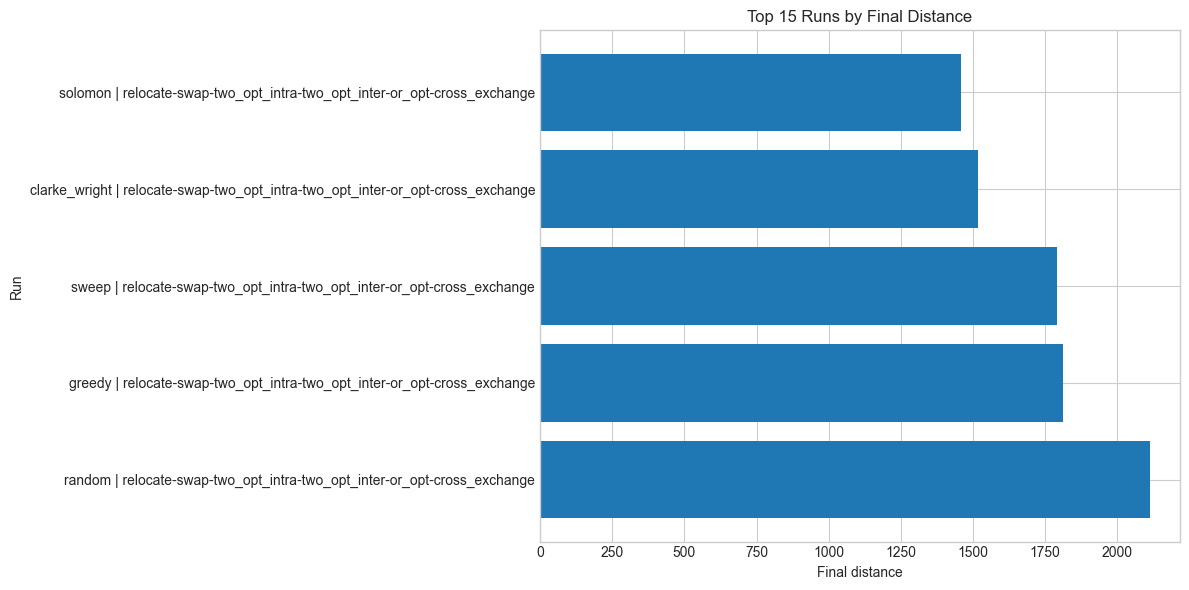

In [ ]:
top_n = 15
top_df = feasible_df.head(top_n).copy()
labels = top_df.apply(lambda r: f"{r['init_method']} | {r.get('operators', 'n/a')}", axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(labels[::-1], top_df["final_distance"][::-1])
ax.set_title(f"Top {top_n} Runs by Final Distance")
ax.set_xlabel("Final distance")
ax.set_ylabel("Run")
plt.tight_layout()
plt.show()

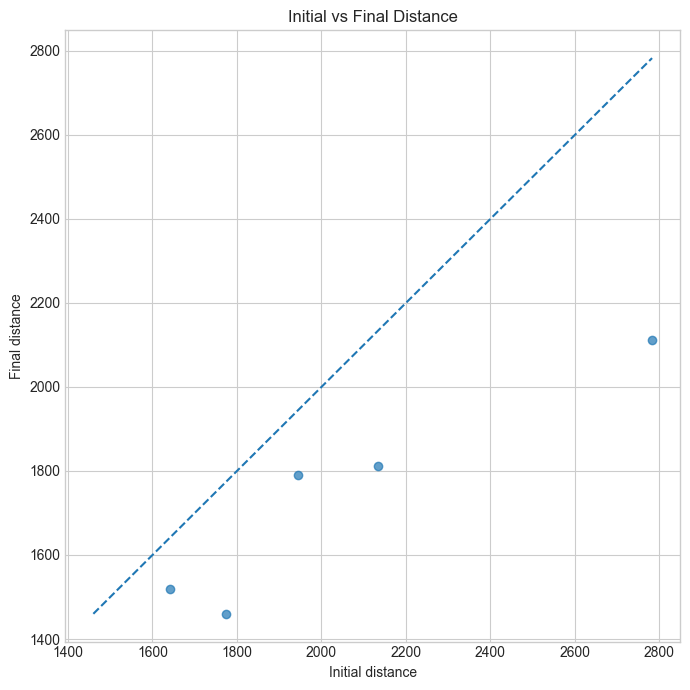

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(feasible_df["initial_distance"], feasible_df["final_distance"], alpha=0.7)

min_val = np.nanmin([feasible_df["initial_distance"].min(), feasible_df["final_distance"].min()])
max_val = np.nanmax([feasible_df["initial_distance"].max(), feasible_df["final_distance"].max()])
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

ax.set_title("Initial vs Final Distance")
ax.set_xlabel("Initial distance")
ax.set_ylabel("Final distance")
plt.tight_layout()
plt.show()

In [ ]:
summary_df = summary_metrics(comparison_df)
summary_df

,metric,value
0,total_runs,5
1,feasible_runs,5
2,best_final_distance,1459.996546
3,median_final_distance,1791.462011
4,best_init_method,solomon
5,best_operators,relocate-swap-two_opt_intra-two_opt_inter-or_o...


In [ ]:
iteration_df = pd.DataFrame()
if latest_log is not None:
    jsonl_rows = load_jsonl(latest_log)
    events = []
    for row in jsonl_rows:
        payload = row.get("payload", {})
        event_name = payload.get("event", row.get("event"))
        if payload.get("iteration") is None:
            continue
        events.append(
            {
                "iteration": int(payload.get("iteration", -1)),
                "event": event_name,
                "current_cost": pd.to_numeric(payload.get("current_cost"), errors="coerce"),
                "best_cost": pd.to_numeric(payload.get("best_cost"), errors="coerce"),
                "elapsed_sec": pd.to_numeric(payload.get("elapsed_sec"), errors="coerce"),
            }
        )
    iteration_df = pd.DataFrame(events)

print(f"Parsed iteration rows: {len(iteration_df)}")
iteration_df.head()

Parsed iteration rows: 41


,iteration,event,current_cost,best_cost,elapsed_sec
0,0,start,1944.986304,1944.986304,0.000000
1,1,improvement,1935.126848,1935.126848,0.032112
2,2,improvement,1927.441018,1927.441018,0.062975
3,3,improvement,1907.381362,1907.381362,0.095402
4,4,improvement,1903.027608,1903.027608,0.131334


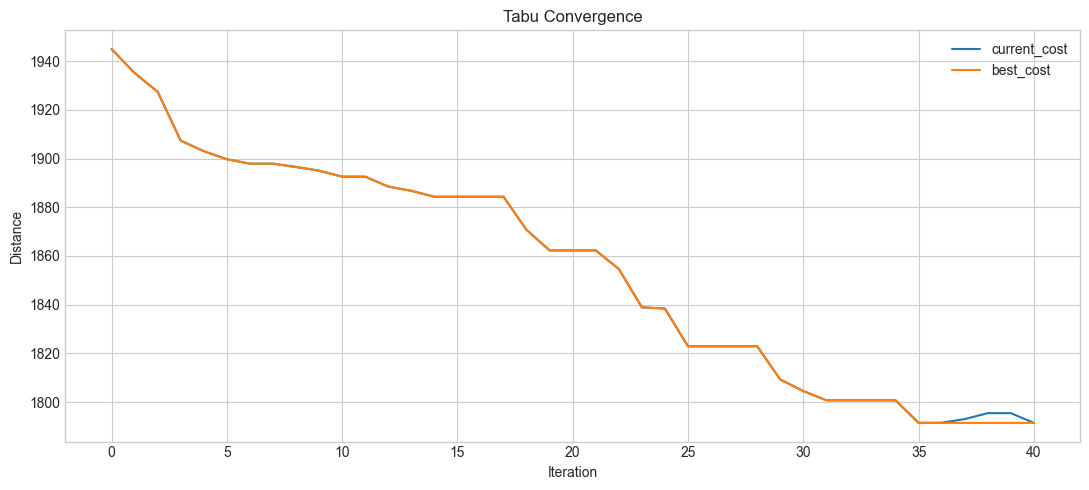

In [ ]:
if len(iteration_df) > 0:
    plot_df = iteration_df.sort_values("iteration")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(plot_df["iteration"], plot_df["current_cost"], label="current_cost")
    ax.plot(plot_df["iteration"], plot_df["best_cost"], label="best_cost")
    ax.set_title("Tabu Convergence")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Distance")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No iteration data available in latest log.")

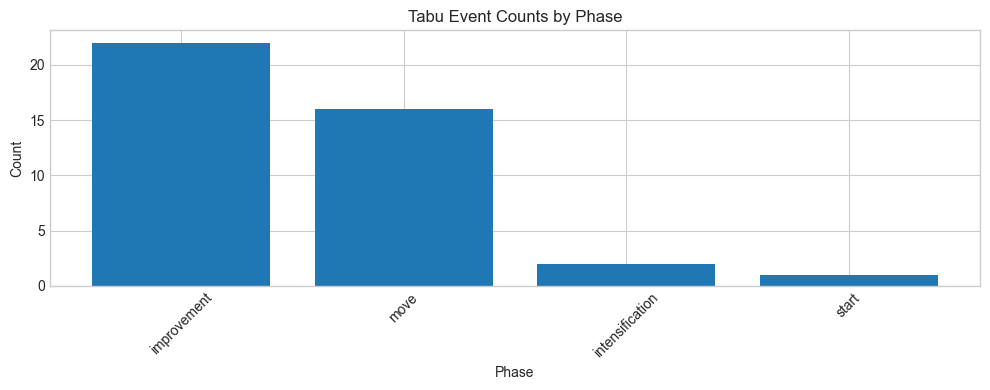

In [ ]:
if len(iteration_df) > 0:
    event_counts = iteration_df["event"].value_counts().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(event_counts.index.astype(str), event_counts.values)
    ax.set_title("Tabu Event Counts by Phase")
    ax.set_xlabel("Phase")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No event data available in latest log.")

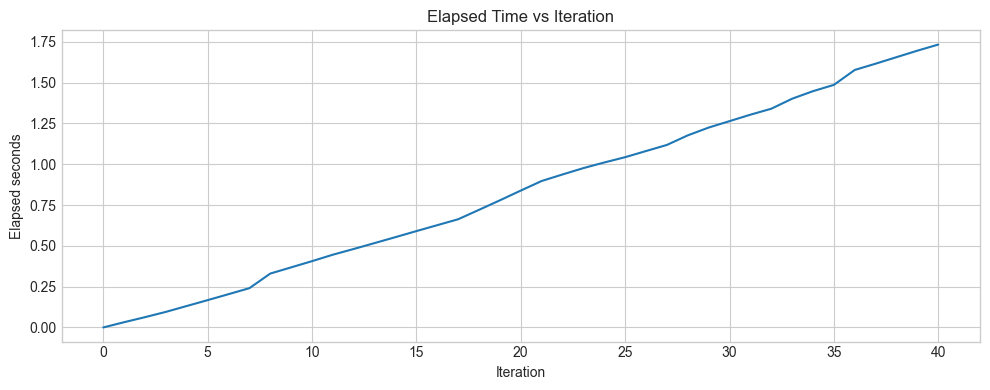

Approx. total tabu time: 1.733s
Approx. avg time per iteration: 0.0433s


In [ ]:
if len(iteration_df) > 0 and iteration_df["elapsed_sec"].notna().any():
    tdf = iteration_df.sort_values("iteration")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(tdf["iteration"], tdf["elapsed_sec"])
    ax.set_title("Elapsed Time vs Iteration")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Elapsed seconds")
    plt.tight_layout()
    plt.show()

    valid_iter = tdf[tdf["iteration"] > 0]
    if len(valid_iter) > 0:
        total_time = float(valid_iter["elapsed_sec"].max())
        avg_time_iter = total_time / len(valid_iter)
        print(f"Approx. total tabu time: {total_time:.3f}s")
        print(f"Approx. avg time per iteration: {avg_time_iter:.4f}s")
else:
    print("No elapsed_sec data found in iteration log.")

## 7. Add Quick Validation Tests

Simple assertions to catch common data and plotting-prep issues early.

In [ ]:
assert "final_distance" in comparison_df.columns, "Missing final_distance column"
assert comparison_df["final_distance"].notna().any(), "No numeric final_distance values found"
assert comparison_df["feasible"].dtype == bool, "feasible column was not converted to bool"
assert len(feasible_df) <= len(comparison_df), "feasible_df cannot be larger than source dataframe"

if len(iteration_df) > 0:
    assert (iteration_df["iteration"] >= 0).all(), "Iteration index must be non-negative"

print("Quick validation tests passed.")

Quick validation tests passed.


## Interpretation Checklist

Use this checklist after running all cells:
- Is the best final distance clearly below most runs?
- Are points mostly below the y=x line (improvement over initial)?
- Does best_cost converge and stabilize in tabu iterations?
- Are there too many diversification phases (possible parameter tuning need)?
- Is average time per iteration acceptable for larger experiment batches?

## 5.5. Run Benchmark and Export Data

Run the benchmark from the notebook and export a comparison CSV plus per-run JSONL logs so the analysis cells have data to load.

In [ ]:
import sys
from datetime import datetime
import itertools

src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from init.methods import get_initial_methods
from heuristics.tabu_search import tabu_search, print_solution
from utils.checker import evaluate_solution, maybe_repair_to_vehicle_limit
from utils.parser import parse_instance

# Benchmark settings for the notebook run.
BENCHMARK_INSTANCE = "R105"
BENCHMARK_SEED = 0
BENCHMARK_INIT_METHODS = ["greedy", "solomon", "clarke_wright", "random", "sweep"]
BENCHMARK_OPERATORS = ["relocate", "swap", "two_opt_intra", "two_opt_inter", "or_opt", "cross_exchange"]
BENCHMARK_ITERATIONS = 40
BENCHMARK_TENURE = 12
BENCHMARK_ASPIRATION = True
BENCHMARK_DIVERSIFICATION_INTERVAL = 25
BENCHMARK_INTENSIFICATION_INTERVAL = 20
BENCHMARK_PER_OPERATOR_MOVES = 25
BENCHMARK_APPLY_FLEET_REPAIR = True
BENCHMARK_ALL_OPERATOR_COMBOS = False  # set True to evaluate all subsets
BENCHMARK_MAX_COMBO_SIZE = 2           # only used when BENCHMARK_ALL_OPERATOR_COMBOS is True

problem = parse_instance(BENCHMARK_INSTANCE)
methods = get_initial_methods(seed=BENCHMARK_SEED)

if BENCHMARK_ALL_OPERATOR_COMBOS:
    operator_combos = []
    limit = len(BENCHMARK_OPERATORS) if BENCHMARK_MAX_COMBO_SIZE is None else min(BENCHMARK_MAX_COMBO_SIZE, len(BENCHMARK_OPERATORS))
    for size in range(1, limit + 1):
        operator_combos.extend(itertools.combinations(BENCHMARK_OPERATORS, size))
else:
    operator_combos = [tuple(BENCHMARK_OPERATORS)]

benchmark_rows = []
run_logs_dir = logs_dir
run_logs_dir.mkdir(parents=True, exist_ok=True)
solutions_dir.mkdir(parents=True, exist_ok=True)

print(f"Instance: {problem.name}")
print(f"Operator combinations: {len(operator_combos)}")
print(f"Initial methods: {BENCHMARK_INIT_METHODS}")

for init_method in BENCHMARK_INIT_METHODS:
    if init_method not in methods:
        continue

    init_start = datetime.now()
    initial_routes = methods[init_method](problem)
    initial_routes, init_repair_note = maybe_repair_to_vehicle_limit(
        problem,
        initial_routes,
        apply_fleet_repair=BENCHMARK_APPLY_FLEET_REPAIR,
    )
    init_ok, init_distance, init_msg = evaluate_solution(problem, initial_routes)
    init_elapsed = (datetime.now() - init_start).total_seconds()

    for combo in operator_combos:
        combo_name = "-".join(combo)
        log_path = run_logs_dir / f"notebook_{problem.name}_{init_method}_{combo_name}.jsonl"

        iteration_records = []

        def capture_iteration(payload):
            payload = dict(payload)
            iteration_records.append(payload)

        best_routes, best_cost = tabu_search(
            problem=problem,
            initial_routes=initial_routes,
            iterations=BENCHMARK_ITERATIONS,
            tabu_tenure=BENCHMARK_TENURE,
            aspiration=BENCHMARK_ASPIRATION,
            diversification_interval=BENCHMARK_DIVERSIFICATION_INTERVAL,
            intensification_interval=BENCHMARK_INTENSIFICATION_INTERVAL,
            per_operator_moves=BENCHMARK_PER_OPERATOR_MOVES,
            enabled_operators=list(combo),
            iteration_callback=capture_iteration,
            apply_fleet_repair=BENCHMARK_APPLY_FLEET_REPAIR,
            random_seed=BENCHMARK_SEED,
        )

        final_ok, final_distance, final_msg = evaluate_solution(problem, best_routes)
        final_distance = min(final_distance, best_cost)

        # Write JSONL log for this run.
        with log_path.open("w", encoding="utf-8") as handle:
            handle.write(json.dumps({"event": "initial_solution", "payload": {"init_method": init_method, "distance": init_distance, "feasible": init_ok, "elapsed_sec": init_elapsed}}) + "\n")
            for payload in iteration_records:
                handle.write(json.dumps({"event": "tabu_iteration", "payload": payload}) + "\n")
            handle.write(json.dumps({"event": "final_solution", "payload": {"final_distance": final_distance, "feasible": final_ok, "message": final_msg}}) + "\n")

        benchmark_rows.append(
            {
                "instance": problem.name,
                "init_method": init_method,
                "operators": combo_name,
                "initial_distance": init_distance,
                "final_distance": final_distance,
                "feasible": final_ok,
                "initial_feasible": init_ok,
                "init_time_sec": init_elapsed,
                "iterations": BENCHMARK_ITERATIONS,
                "log_file": str(log_path),
                "initial_message": init_msg if not init_ok else "OK",
                "final_message": final_msg,
            }
        )

        print_solution(f"Benchmark {init_method} | {combo_name}", best_routes, final_distance, final_ok, final_msg)

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_csv = solutions_dir / f"comparison_{problem.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
benchmark_df.to_csv(benchmark_csv, index=False)

print(f"Exported CSV: {benchmark_csv}")
print(f"Exported logs: {len(benchmark_rows)} files to {run_logs_dir}")
benchmark_df.head()

Instance: R105
Operator combinations: 1
Initial methods: ['greedy', 'solomon', 'clarke_wright', 'random', 'sweep']
Method: Benchmark greedy | relocate-swap-two_opt_intra-two_opt_inter-or_opt-cross_exchange
Feasible: True
Total distance: 1810.67
Routes: 20
Status: OK
Route 1: 0 -> 31 -> 88 -> 7 -> 0
Route 2: 0 -> 53 -> 0
Route 3: 0 -> 40 -> 73 -> 74 -> 0
Route 4: 0 -> 18 -> 6 -> 94 -> 96 -> 0
Route 5: 0 -> 95 -> 92 -> 37 -> 100 -> 91 -> 93 -> 0
Route 6: 0 -> 99 -> 85 -> 84 -> 43 -> 58 -> 0
Route 7: 0 -> 59 -> 98 -> 61 -> 16 -> 86 -> 46 -> 48 -> 89 -> 0
Route 8: 0 -> 2 -> 15 -> 57 -> 87 -> 26 -> 0
Route 9: 0 -> 21 -> 75 -> 41 -> 22 -> 56 -> 4 -> 54 -> 80 -> 0
Route 10: 0 -> 5 -> 83 -> 8 -> 49 -> 32 -> 0
Route 11: 0 -> 72 -> 39 -> 23 -> 67 -> 55 -> 25 -> 0
Route 12: 0 -> 82 -> 47 -> 19 -> 10 -> 20 -> 1 -> 70 -> 0
Route 13: 0 -> 33 -> 76 -> 81 -> 9 -> 34 -> 0
Route 14: 0 -> 27 -> 69 -> 30 -> 51 -> 79 -> 66 -> 0
Route 15: 0 -> 42 -> 14 -> 44 -> 38 -> 97 -> 13 -> 0
Route 16: 0 -> 52 -> 62 ->

,instance,init_method,operators,initial_distance,final_distance,feasible,initial_feasible,init_time_sec,iterations,log_file,initial_message,final_message
0,R105,greedy,relocate-swap-two_opt_intra-two_opt_inter-or_o...,2132.883169,1810.670949,True,True,0.028455,40,c:\Users\Jed\Desktop\9raya\heuristiques\result...,OK,OK
1,R105,solomon,relocate-swap-two_opt_intra-two_opt_inter-or_o...,1774.414359,1459.996546,True,True,0.177457,40,c:\Users\Jed\Desktop\9raya\heuristiques\result...,OK,OK
2,R105,clarke_wright,relocate-swap-two_opt_intra-two_opt_inter-or_o...,1640.989084,1519.179879,True,True,0.050010,40,c:\Users\Jed\Desktop\9raya\heuristiques\result...,OK,OK
3,R105,random,relocate-swap-two_opt_intra-two_opt_inter-or_o...,2782.680205,2111.764309,True,True,0.022563,40,c:\Users\Jed\Desktop\9raya\heuristiques\result...,OK,OK
4,R105,sweep,relocate-swap-two_opt_intra-two_opt_inter-or_o...,1944.986304,1791.462011,True,True,0.009546,40,c:\Users\Jed\Desktop\9raya\heuristiques\result...,OK,OK


## 5.6. Benchmark Export Validation

Validate the exported files immediately so the later analysis cells can run without manual setup.

In [ ]:
assert benchmark_csv.exists(), "Benchmark CSV was not created"
assert len(list(run_logs_dir.glob("notebook_*.jsonl"))) > 0, "No JSONL logs were created"
assert len(benchmark_df) > 0, "Benchmark dataframe is empty"
print("Benchmark export validation passed.")

Benchmark export validation passed.
